## logistic regression project
Project explores a customer data set. Task is to identify customers who are more likely to invest in a long-term deposit.

In [52]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
main_df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=413&path=bank-marketing-campaign-data.csv", sep=';')

main_df.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# EDA

In [54]:
main_df.shape

(41188, 21)

In [55]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [56]:
main_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [57]:
# target
main_df['y'].value_counts()

y
no     36548
yes     4640
Name: count, dtype: int64

In [58]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [59]:
#re-naming some columns for readability
main_df.rename(columns={'marital': 'marital_status', 'default': 'currently_has_credit', 'housing': 'has_housing_loan', 'loan': 'has_personal_loan', 'contact': 'contact_method', 'month': 'last_month_of_contact', 'day_of_week': 'last_day_of_week_contacted', 'duration': 'duration_of_last_contact_seconds', 'campaign': 'num_of_contacts_current_campaign', 'previous': 'num_of_contacts_prev_campaign', 'poutcome': 'prev_campaign_outcome', 'emp.var.rate': 'emp_variation_rate', 'cons.price.idx': 'cons_price_idx', 'cons.conf.idx': 'cons_conf_idx', 'nr.employed': 'num_of_employees'}, inplace=True)

# Deep dive into feature relationships

Number of contacts during previous campaign, and previous campaign outcome.

In [60]:
# Customers who were contacted between 2 + times seem to have a higher liklihood of contributing to the previous campaign 

main_df.groupby('num_of_contacts_prev_campaign')['prev_campaign_outcome'].value_counts(normalize=True)

num_of_contacts_prev_campaign  prev_campaign_outcome
0                              nonexistent              1.000000
1                              failure                  0.810349
                               success                  0.189651
2                              failure                  0.575597
                               success                  0.424403
3                              success                  0.592593
                               failure                  0.407407
4                              success                  0.571429
                               failure                  0.428571
5                              success                  0.833333
                               failure                  0.166667
6                              success                  0.800000
                               failure                  0.200000
7                              success                  1.000000
Name: proportion, dtype: float64

<Figure size 500x400 with 0 Axes>

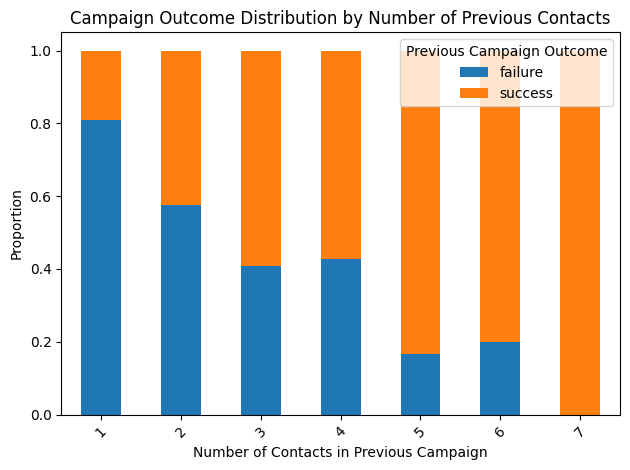

In [61]:
# It's important to note sample size becomes significantly less the more contacts were made.

prev_outcome_counts = main_df[main_df['prev_campaign_outcome'] != 'nonexistent'].groupby('num_of_contacts_prev_campaign')['prev_campaign_outcome'].value_counts()
prepped_prev_outcome = main_df[main_df['prev_campaign_outcome'] != 'nonexistent'].groupby('num_of_contacts_prev_campaign')['prev_campaign_outcome'].value_counts(normalize=True).unstack()

plt.figure(figsize=(5,4))

prepped_prev_outcome.plot(kind='bar', stacked=True)

plt.xlabel('Number of Contacts in Previous Campaign')
plt.ylabel('Proportion')
plt.title('Campaign Outcome Distribution by Number of Previous Contacts')
plt.legend(title='Previous Campaign Outcome')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
prev_outcome_counts

num_of_contacts_prev_campaign  prev_campaign_outcome
1                              failure                  3696
                               success                   865
2                              failure                   434
                               success                   320
3                              success                   128
                               failure                    88
4                              success                    40
                               failure                    30
5                              success                    15
                               failure                     3
6                              success                     4
                               failure                     1
7                              success                     1
Name: count, dtype: int64

Previous yes and current yes

In [63]:
main_df[main_df['prev_campaign_outcome']!='nonexistent'].groupby('y')['prev_campaign_outcome'].value_counts() 

y    prev_campaign_outcome
no   failure                  3647
     success                   479
yes  success                   894
     failure                   605
Name: count, dtype: int64

<Axes: xlabel='age', ylabel='Probability'>

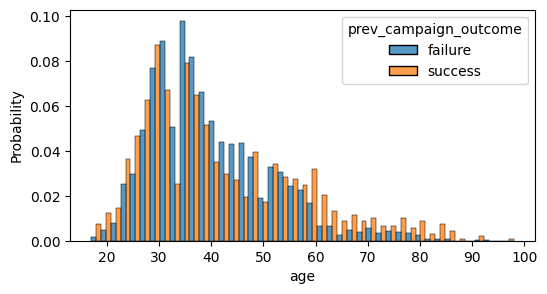

In [64]:
# Age tells us: *something* about the distribution of last years campaign, but what is unknown at this time.
plt.figure(figsize=(6,3))
sns.histplot(data = main_df[main_df['prev_campaign_outcome']!='nonexistent'], x='age', 
             hue='prev_campaign_outcome', multiple='dodge', stat='probability', common_norm=False)

In [65]:
# Education: University degrees seem to have a higher success rate
main_df[main_df['prev_campaign_outcome'] != 'nonexistent'].groupby('education')['prev_campaign_outcome'].value_counts(normalize=True)


education            prev_campaign_outcome
basic.4y             failure                  0.737500
                     success                  0.262500
basic.6y             failure                  0.844961
                     success                  0.155039
basic.9y             failure                  0.850202
                     success                  0.149798
high.school          failure                  0.791932
                     success                  0.208068
illiterate           failure                  0.500000
                     success                  0.500000
professional.course  failure                  0.733236
                     success                  0.266764
university.degree    failure                  0.699718
                     success                  0.300282
unknown              failure                  0.685185
                     success                  0.314815
Name: proportion, dtype: float64

In [66]:
# Economic indicators
main_df.groupby('cons_price_idx')['y'].value_counts(normalize=True)


cons_price_idx  y  
92.201          no     0.657143
                yes    0.342857
92.379          no     0.602996
                yes    0.397004
92.431          no     0.597315
                yes    0.402685
92.469          no     0.629213
                yes    0.370787
92.649          no     0.529412
                yes    0.470588
92.713          yes    0.511628
                no     0.488372
92.756          no     0.900000
                yes    0.100000
92.843          no     0.553191
                yes    0.446809
92.893          no     0.909562
                yes    0.090438
92.963          no     0.630769
                yes    0.369231
93.075          no     0.820179
                yes    0.179821
93.200          no     0.947456
                yes    0.052544
93.369          yes    0.568182
                no     0.431818
93.444          no     0.947633
                yes    0.052367
93.749          yes    0.557471
                no     0.442529
93.798          yes 

In [67]:
# Education + Econ
main_df['low_interest_rates'] = main_df['euribor3m'].apply(lambda x: x < 3)
main_df['is_college_grad'] = main_df['education'].apply(lambda x: x == 'university.degree')

In [68]:
main_df.head()

,age,job,marital_status,education,currently_has_credit,has_housing_loan,has_personal_loan,contact_method,last_month_of_contact,last_day_of_week_contacted,duration_of_last_contact_seconds,num_of_contacts_current_campaign,pdays,num_of_contacts_prev_campaign,prev_campaign_outcome,emp_variation_rate,cons_price_idx,cons_conf_idx,euribor3m,num_of_employees,y,low_interest_rates,is_college_grad
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False,False
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False,False


In [69]:
included_features = ['age', 'job', 'is_college_grad', 'has_housing_loan', 
                     'has_personal_loan', 'duration_of_last_contact_seconds', 'num_of_contacts_current_campaign',
                     'emp_variation_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'low_interest_rates', 'is_college_grad']


In [70]:
from sklearn.model_selection import train_test_split

In [71]:
X = main_df[included_features]
y = main_df['y']

In [72]:
X.head()

,age,job,is_college_grad,has_housing_loan,has_personal_loan,duration_of_last_contact_seconds,num_of_contacts_current_campaign,emp_variation_rate,cons_price_idx,cons_conf_idx,euribor3m,low_interest_rates,is_college_grad
0,56,housemaid,False,no,no,261,1,1.1,93.994,-36.4,4.857,False,False
1,57,services,False,no,no,149,1,1.1,93.994,-36.4,4.857,False,False
2,37,services,False,yes,no,226,1,1.1,93.994,-36.4,4.857,False,False
3,40,admin.,False,no,no,151,1,1.1,93.994,-36.4,4.857,False,False
4,56,services,False,no,yes,307,1,1.1,93.994,-36.4,4.857,False,False


In [73]:
X_dummies = pd.get_dummies(X, drop_first=True)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y)

In [75]:
X_train.shape

(30891, 25)

In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
logreg_model = LogisticRegression(max_iter=1000)

logreg_model.fit(X_train, y_train)


/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
train_preds = logreg_model.predict(X_train)
test_preds = logreg_model.predict(X_test)

In [79]:
# Evaluation methods include
# Accuracy
# Confusion matrix methods

In [80]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [81]:
print("training prediction accuracy:")
accuracy_score(y_true= y_train, y_pred=train_preds)

print("training confusion matrix:")
print(confusion_matrix(y_true=y_train, y_pred=train_preds))

print("classification report")
print(classification_report(y_true=y_train, y_pred=train_preds))

training prediction accuracy:
training confusion matrix:
[[26740   637]
 [ 2385  1129]]
classification report


              precision    recall  f1-score   support

          no       0.92      0.98      0.95     27377
         yes       0.64      0.32      0.43      3514

    accuracy                           0.90     30891
   macro avg       0.78      0.65      0.69     30891
weighted avg       0.89      0.90      0.89     30891



In [82]:
print("test prediction accuracy:")
print(accuracy_score(y_true= y_test, y_pred=test_preds))

print("test confusion matrix:")
print(confusion_matrix(y_true=y_test, y_pred=test_preds))

print("classification report")
print(classification_report(y_true=y_test, y_pred=test_preds))

test prediction accuracy:
0.9015247159366806
test confusion matrix:
[[8938  233]
 [ 781  345]]
classification report
              precision    recall  f1-score   support

          no       0.92      0.97      0.95      9171
         yes       0.60      0.31      0.40      1126

    accuracy                           0.90     10297
   macro avg       0.76      0.64      0.68     10297
weighted avg       0.88      0.90      0.89     10297



<Axes: >

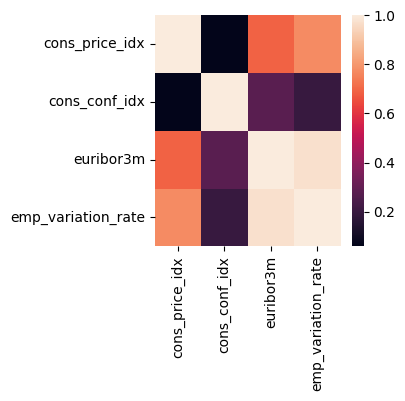

In [88]:
plt.figure(figsize=(3,3))
sns.heatmap(main_df[['cons_price_idx', 'cons_conf_idx', 'euribor3m', 'emp_variation_rate']].corr())

In [89]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               41188 non-null  int64  
 1   job                               41188 non-null  object 
 2   marital_status                    41188 non-null  object 
 3   education                         41188 non-null  object 
 4   currently_has_credit              41188 non-null  object 
 5   has_housing_loan                  41188 non-null  object 
 6   has_personal_loan                 41188 non-null  object 
 7   contact_method                    41188 non-null  object 
 8   last_month_of_contact             41188 non-null  object 
 9   last_day_of_week_contacted        41188 non-null  object 
 10  duration_of_last_contact_seconds  41188 non-null  int64  
 11  num_of_contacts_current_campaign  41188 non-null  int64  
 12  pday

In [92]:
def jobs_restructure(x):
    if x in ['admin.', 'blue-collar', 'technician']:
        return x
    return 'other'

main_df['job'] = main_df['job'].apply(jobs_restructure)

In [94]:
main_df['job'].value_counts()

job
other          14769
admin.         10422
blue-collar     9254
technician      6743
Name: count, dtype: int64

In [95]:
main_df = main_df.drop(columns='education')

In [101]:
main_df['currently_has_credit'] = main_df['currently_has_credit'].map({'unknown': 'unknown', 'no': 'no', 'yes': 'unknown'})

In [106]:
main_df['duration_of_last_contact_seconds'] = np.log(main_df['duration_of_last_contact_seconds'] + 1)

In [107]:
main_df.head(3)

,age,job,marital_status,currently_has_credit,has_housing_loan,has_personal_loan,contact_method,last_month_of_contact,last_day_of_week_contacted,duration_of_last_contact_seconds,num_of_contacts_current_campaign,pdays,num_of_contacts_prev_campaign,prev_campaign_outcome,emp_variation_rate,cons_price_idx,cons_conf_idx,euribor3m,num_of_employees,y,low_interest_rates,is_college_grad
0,56,other,married,no,no,no,telephone,may,mon,5.568345,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False,False
1,57,other,married,unknown,no,no,telephone,may,mon,5.010635,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False,False
2,37,other,married,no,yes,no,telephone,may,mon,5.424950,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False,False


In [ ]:
new_df = main_df.drop(columns='y')
X = new_df
y = main_df['y'] 


In [111]:
X_dummies = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X_dummies, y)
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)
train_preds = logreg_model.predict(X_train)
test_preds = logreg_model.predict(X_test)

/home/vscode/.local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [112]:
print("training prediction accuracy:")
accuracy_score(y_true= y_train, y_pred=train_preds)

print("training confusion matrix:")
print(confusion_matrix(y_true=y_train, y_pred=train_preds))

print("classification report")
print(classification_report(y_true=y_train, y_pred=train_preds))

training prediction accuracy:
training confusion matrix:
[[26619   787]
 [ 1951  1534]]
classification report
              precision    recall  f1-score   support

          no       0.93      0.97      0.95     27406
         yes       0.66      0.44      0.53      3485

    accuracy                           0.91     30891
   macro avg       0.80      0.71      0.74     30891
weighted avg       0.90      0.91      0.90     30891



In [113]:
print("test prediction accuracy:")
print(accuracy_score(y_true= y_test, y_pred=test_preds))

print("test confusion matrix:")
print(confusion_matrix(y_true=y_test, y_pred=test_preds))

print("classification report")
print(classification_report(y_true=y_test, y_pred=test_preds))

test prediction accuracy:
0.9090026221229485
test confusion matrix:
[[8853  289]
 [ 648  507]]
classification report
              precision    recall  f1-score   support

          no       0.93      0.97      0.95      9142
         yes       0.64      0.44      0.52      1155

    accuracy                           0.91     10297
   macro avg       0.78      0.70      0.73     10297
weighted avg       0.90      0.91      0.90     10297

